In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [10]:
import pandas as pd

data = pd.read_csv(r"C:\Users\it king\Projects\startup_profit_prediction\50_startups_dataset.csv")

In [11]:
# What type is this?
print(f"Type: {type(data)}")
print(f"Shape: {data.shape}  →  {data.shape[0]} rows, {data.shape[1]} columns")

Type: <class 'pandas.DataFrame'>
Shape: (50, 5)  →  50 rows, 5 columns


In [12]:
# First 5 rows - always start here!
data.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,Pakistan,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Istanbul,191050.39
3,144372.41,118671.85,383199.62,Pakistan,182901.99
4,142107.34,91391.77,366168.42,Istanbul,166187.94


In [13]:
# Last 3 rows
data.tail(3)

,R&D Spend,Administration,Marketing Spend,State,Profit
47,0.00,135426.92,0.00,California,42559.73
48,542.05,51743.15,0.00,Pakistan,35673.41
49,0.00,116983.80,45173.06,California,14681.40


In [14]:
# Random sample - good for spotting patterns
data.sample(3)

,R&D Spend,Administration,Marketing Spend,State,Profit
28,66051.52,182645.56,118148.20,Istanbul,103282.38
22,73994.56,122782.75,303319.26,Istanbul,110352.25
40,28754.33,118546.05,172795.67,California,78239.91


In [15]:
# Dataset info - data types, null counts, memory usage
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.1 KB


In [16]:
# Column names
print(f"Columns: {list(data.columns)}")

Columns: ['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit']


In [17]:
# Statistical summary - the most important EDA command
data.describe().T

,count,mean,std,min,25%,50%,75%,max
R&D Spend,50.0,73721.6156,45902.256482,0.00,39936.3700,73051.080,101602.8000,165349.20
Administration,50.0,121344.6396,28017.802755,51283.14,103730.8750,122699.795,144842.1800,182645.56
Marketing Spend,50.0,211025.0978,122290.310726,0.00,129300.1325,212716.240,299469.0850,471784.10
Profit,50.0,112012.6392,40306.180338,14681.40,90138.9025,107978.190,139765.9775,192261.83


In [19]:
# Correct for 50 Startups dataset
X = data[['R&D Spend', 'Administration', 'Marketing Spend']]  
y = data['Profit']

In [20]:
# Rows 15 to 20 (exclusive of 21)
data.iloc[15:21]

,R&D Spend,Administration,Marketing Spend,State,Profit
15,114523.61,122616.84,261776.23,Pakistan,129917.04
16,78013.11,121597.55,264346.06,California,126992.93
17,94657.16,145077.58,282574.31,Pakistan,125370.37
18,91749.16,114175.79,294919.57,Istanbul,124266.90
19,86419.70,153514.11,0.00,Pakistan,122776.86
20,76253.86,113867.30,298664.47,California,118474.03


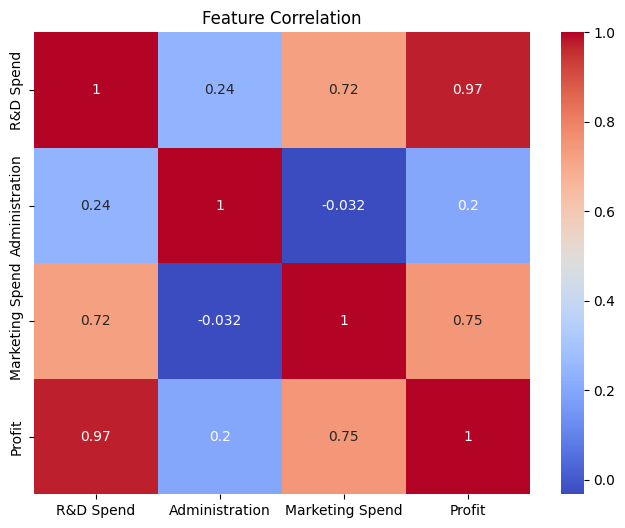

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [24]:
data = pd.get_dummies(data, drop_first=True)

In [25]:
X = data.drop("Profit", axis=1)
y = data["Profit"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
y_pred = model.predict(X_test)

In [29]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R² Score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R² Score: 0.8987266414328636
MAE: 6961.477813252382
MSE: 82010363.04430111
RMSE: 9055.957323458471


In [30]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
3,State_Istanbul,938.793006
4,State_Pakistan,6.987760
0,R&D Spend,0.805630
2,Marketing Spend,0.029855
1,Administration,-0.068788


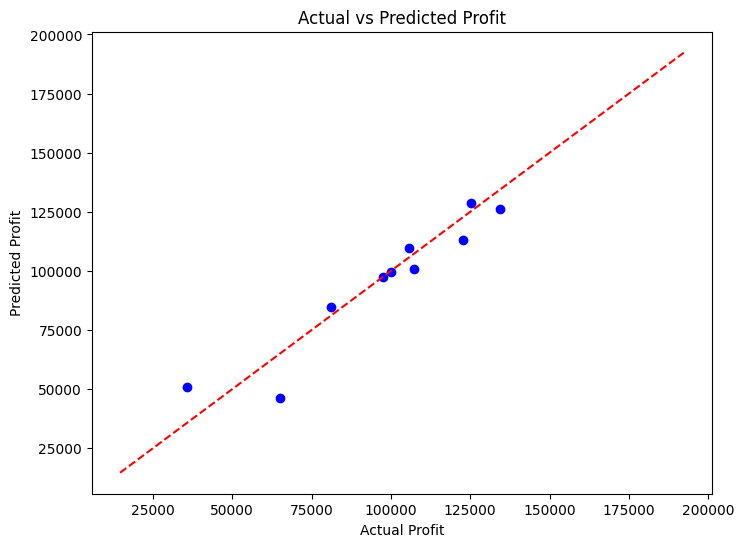

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # perfect line
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")
plt.show()

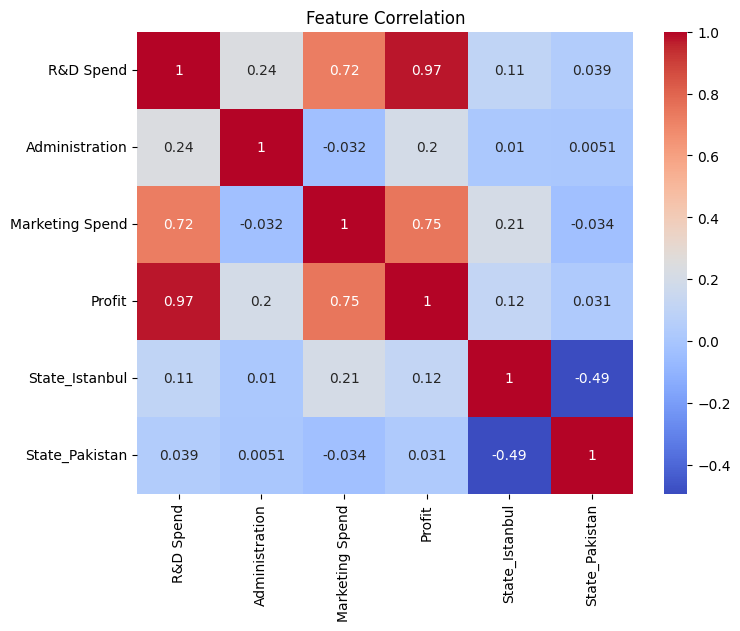

In [33]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()


In [35]:
print(data.columns)

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Istanbul', 'State_Pakistan'],
      dtype='str')


In [36]:
# Include all columns except the target 'Profit'
X = data.drop('Profit', axis=1)
y = data['Profit']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.8987266414328636
MAE: 6961.477813252382
MSE: 82010363.04430111
RMSE: 9055.957323458471


In [40]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print(importance)

           Feature  Coefficient
3   State_Istanbul   938.793006
4   State_Pakistan     6.987760
0        R&D Spend     0.805630
2  Marketing Spend     0.029855
1   Administration    -0.068788
